In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'
# until ~2450 rocket isn't in main phase so it's useless noise
xr = np.genfromtxt('FT1_primary.csv', delimiter=',')[2450:,4]
yr = np.genfromtxt('FT1_primary.csv', delimiter=',')[2450:,19]
# xr = np.genfromtxt('rollControl/Roll-Control/Plotting/DerivativesandSmoothing/FT1_primary.csv', delimiter=',')[2450:,4]
# yr = np.genfromtxt('rollControl/Roll-Control/Plotting/DerivativesandSmoothing/FT1_primary.csv', delimiter=',')[2450:,19]

In [ ]:
class KF:
    def __init__(self, dt, x0, P0, q_alpha, r_phi, r_omega):#, phi0=0, omega0=0, alpha0=0, phi0_var=0.1, omega0_var=0.1, alpha0_var=0.1):
        
        self.x = np.array([[x0[0]], [x0[1]], [x0[2]]]) # (phi, omega, alpha)
        self.dt = dt

        # state estimation matrix
        self.F = np.array([[1, dt, 0.5*dt**2],
                           [0, 1, dt],
                           [0, 0, 1]])
        # control input
        self.G = np.array([[0],[self.dt]])
        # measurement model
        self.H = np.array([[1, 0, 0],
                           [0, 1, 0]])
        # covariances 
        self.Q = np.array([[dt**5 / 20, dt**4 / 8, dt**3 / 6],
                           [dt**4 / 8,  dt**3 / 3, dt**2 / 2],
                           [dt**3 / 6,  dt**2 / 2, dt]]) * q_alpha**2
        self.q_alpha = q_alpha
        self.R = np.array([[r_phi**2, 0],
                           [0, r_omega**2]])

        # state estimation error covariance
        self.P = P0
        
        # for reproducability
        self.randgen = np.random.default_rng(3)

    
    def predict(self, u=0): # no control input (torque) for now
        w_k = np.array([[0], [0], [self.q_alpha**2]]) # random white noise
        self.x = self.F @ self.x + w_k
        self.P = self.F @ self.P @ self.F.T + self.Q
        return self.x.copy(), self.P.copy()
    
    def update(self, z):
        y = z - (self.H @ self.x) # innovation
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)

        self.x = self.x + K @ y
        self.P = (np.eye(3) - K @ self.H) @ self.P


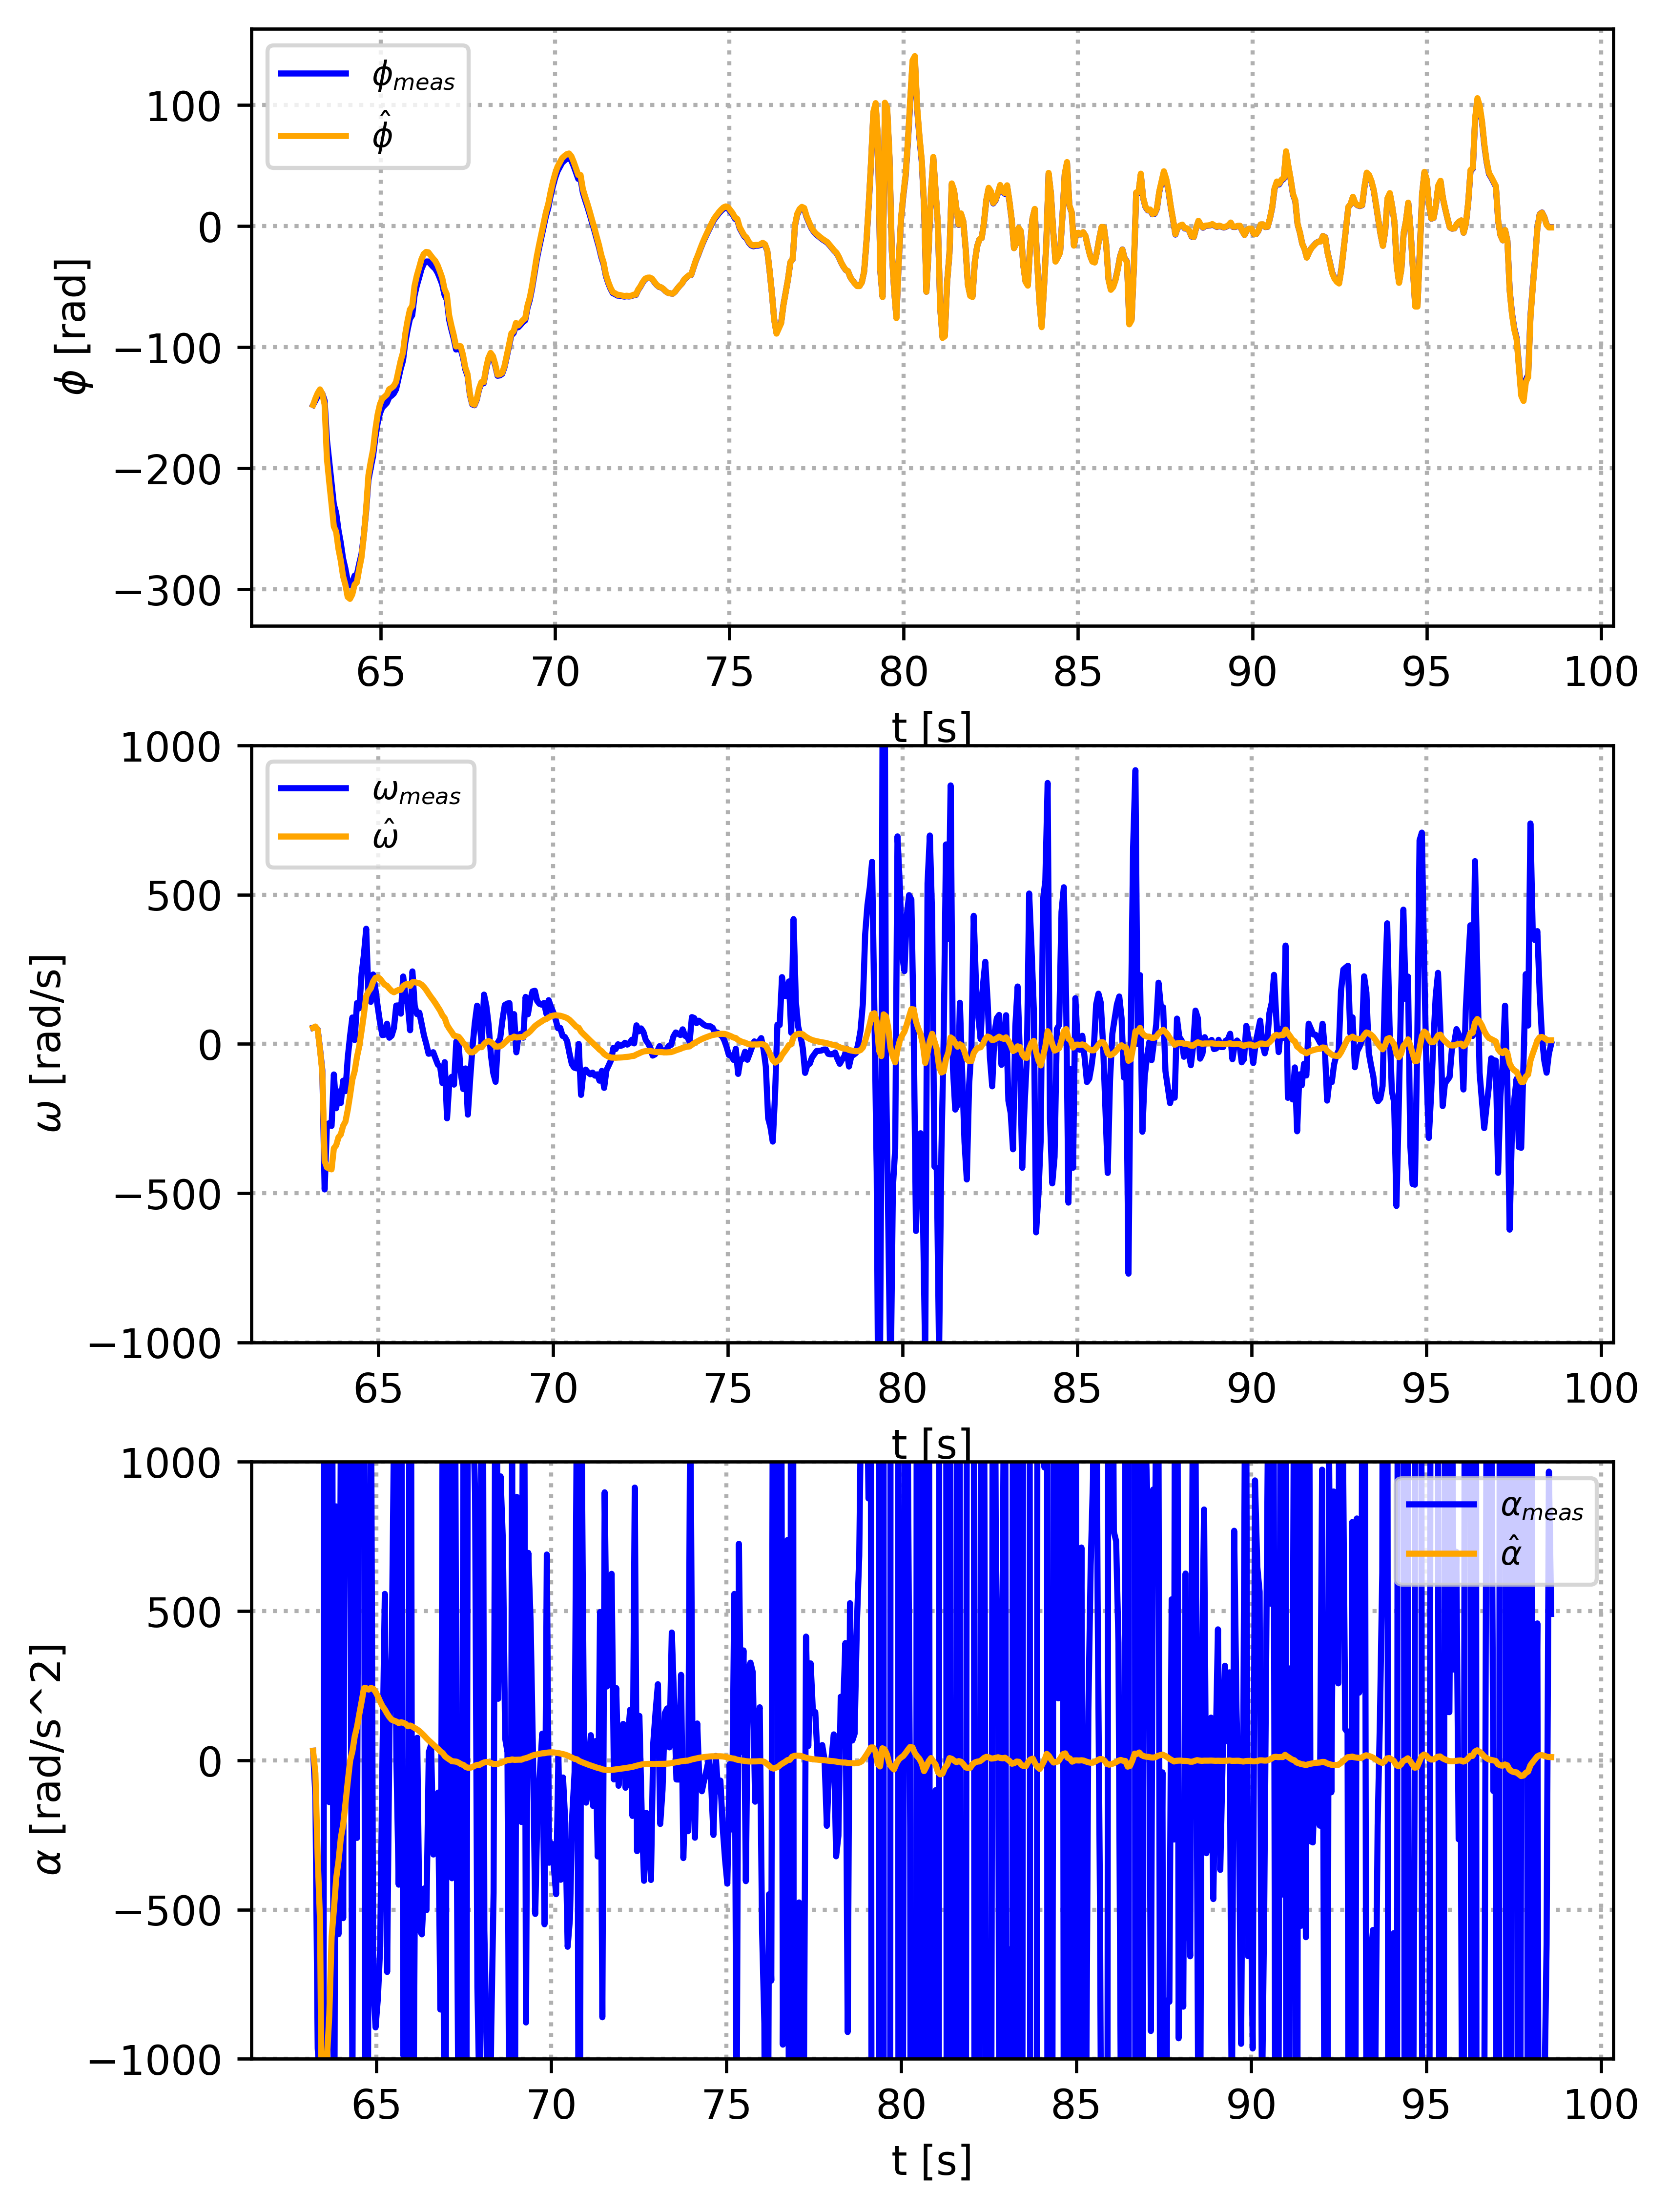

In [4]:
t = np.linspace(xr[0], xr[-1], len(xr))
dt = np.diff(t)[0]
roll = np.interp(t, xr, yr)
omega = np.diff(roll) / dt
alpha = np.diff(omega) / dt
x0 = (roll[0], 0, 0)
x0_acc = np.array([1e-6, 1e-4, 1e-3]) # phi, omega, alpha initial uncertainities
P0 = np.diag(x0_acc)
q_alpha = 1e-5
r_phi = 1e-3
r_omega=1e-4

filter = KF(dt=dt, x0=x0, P0=P0, q_alpha=q_alpha, r_phi=r_phi, r_omega=r_omega)
estimates_log = []
estimates_log.append(np.array(x0).reshape(3,1))
cov_estimates = []
cov_estimates.append(P0)

for k in range(1, len(t)):
    # measurement
    theta_meas = roll[k]
    omega_meas = (roll[k] - roll[k-1]) / dt
    z = np.array([[theta_meas], [omega_meas]])
    filter.update(z)
    x_hat, P_hat = filter.predict()
    estimates_log.append(x_hat)
    cov_estimates.append(P_hat)

estimates_log = np.array(estimates_log)
cov_estimates = np.array(cov_estimates)
fig, axs = plt.subplots(3,1,dpi=300,figsize=(6,9))

# phi
phi_hats = estimates_log[:,0].flatten()
axs[0].plot(t, roll, c='blue', label=r'$\phi_{meas}$')
axs[0].plot(t, phi_hats, c='orange', label=r'$\hat{\phi}$')
axs[0].grid(lw=1, ls=':')
axs[0].set_xlabel('t [s]')
axs[0].set_ylabel(r'$\phi$ [rad]')
axs[0].legend(fontsize=8)

# omega
omega_hats = estimates_log[1:,1].flatten()
axs[1].plot(t[1:], omega, c='blue', label=r'$\omega_{meas}$')
axs[1].plot(t[1:], omega_hats, c='orange', label=r'$\hat{\omega}$')
axs[1].set_ylim(-1000,1000)
axs[1].grid(lw=1, ls=':')
axs[1].set_xlabel('t [s]')
axs[1].set_ylabel(r'$\omega$ [rad/s]')
axs[1].legend(fontsize=8)

# alpha
alpha_hats = estimates_log[2:,2].flatten()
axs[2].plot(t[2:], alpha, c='blue', label=r'$\alpha_{meas}$')
axs[2].plot(t[2:], alpha_hats, c='orange', label=r'$\hat{\alpha}$')
axs[2].set_ylim(-1000,1000)
axs[2].grid(lw=1, ls=':')
axs[2].set_xlabel('t [s]')
axs[2].set_ylabel(r'$\alpha$ [rad/s^2]')
axs[2].legend(fontsize=8);

In [49]:
from scipy.signal import savgol_filter

smoothed_phi = savgol_filter(roll, window_length=5, polyorder=3)
smoothed_omega = savgol_filter(roll, window_length=5, polyorder=3, deriv=1)#np.diff(smoothed_phi) / dt
smoothed_alpha = savgol_filter(roll, window_length=5, polyorder=3, deriv=2)#np.diff(smoothed_omega) / dt
x0 = (roll[0], 0, 0)
x0_acc = np.array([1e-8, 1e-6, 1e-6]) # phi, omega, alpha initial uncertainities
P0 = np.diag(x0_acc)

# vars to adjust
q_alpha = 1e-3
r_phi = 1e-4
r_omega=1e-3

def score_filter_params(q_alpha=q_alpha, r_phi=r_phi, r_omega=r_omega):
    filter = KF(dt=dt, x0=x0, P0=P0, q_alpha=q_alpha, r_phi=r_phi, r_omega=r_omega)
    estimates_log = []
    estimates_log.append(np.array(x0).reshape(3,1))
    cov_estimates = []
    cov_estimates.append(P0)

    for k in range(1, len(t)):
        # measurement
        theta_meas = roll[k]
        omega_meas = (roll[k] - roll[k-1]) / dt
        z = np.array([[theta_meas], [omega_meas]])
        filter.update(z)
        x_hat, P_hat = filter.predict()
        estimates_log.append(x_hat)
       # cov_estimates.append(P_hat)

    estimates_log = np.array(estimates_log)
   # cov_estimates = np.array(cov_estimates)

    # RMSE from "truth"
    phi_hat = estimates_log[:,0].flatten()
    score = np.sqrt(np.sum((phi_hat - smoothed_phi)**2) / len(phi_hat)) 
    return score, phi_hat


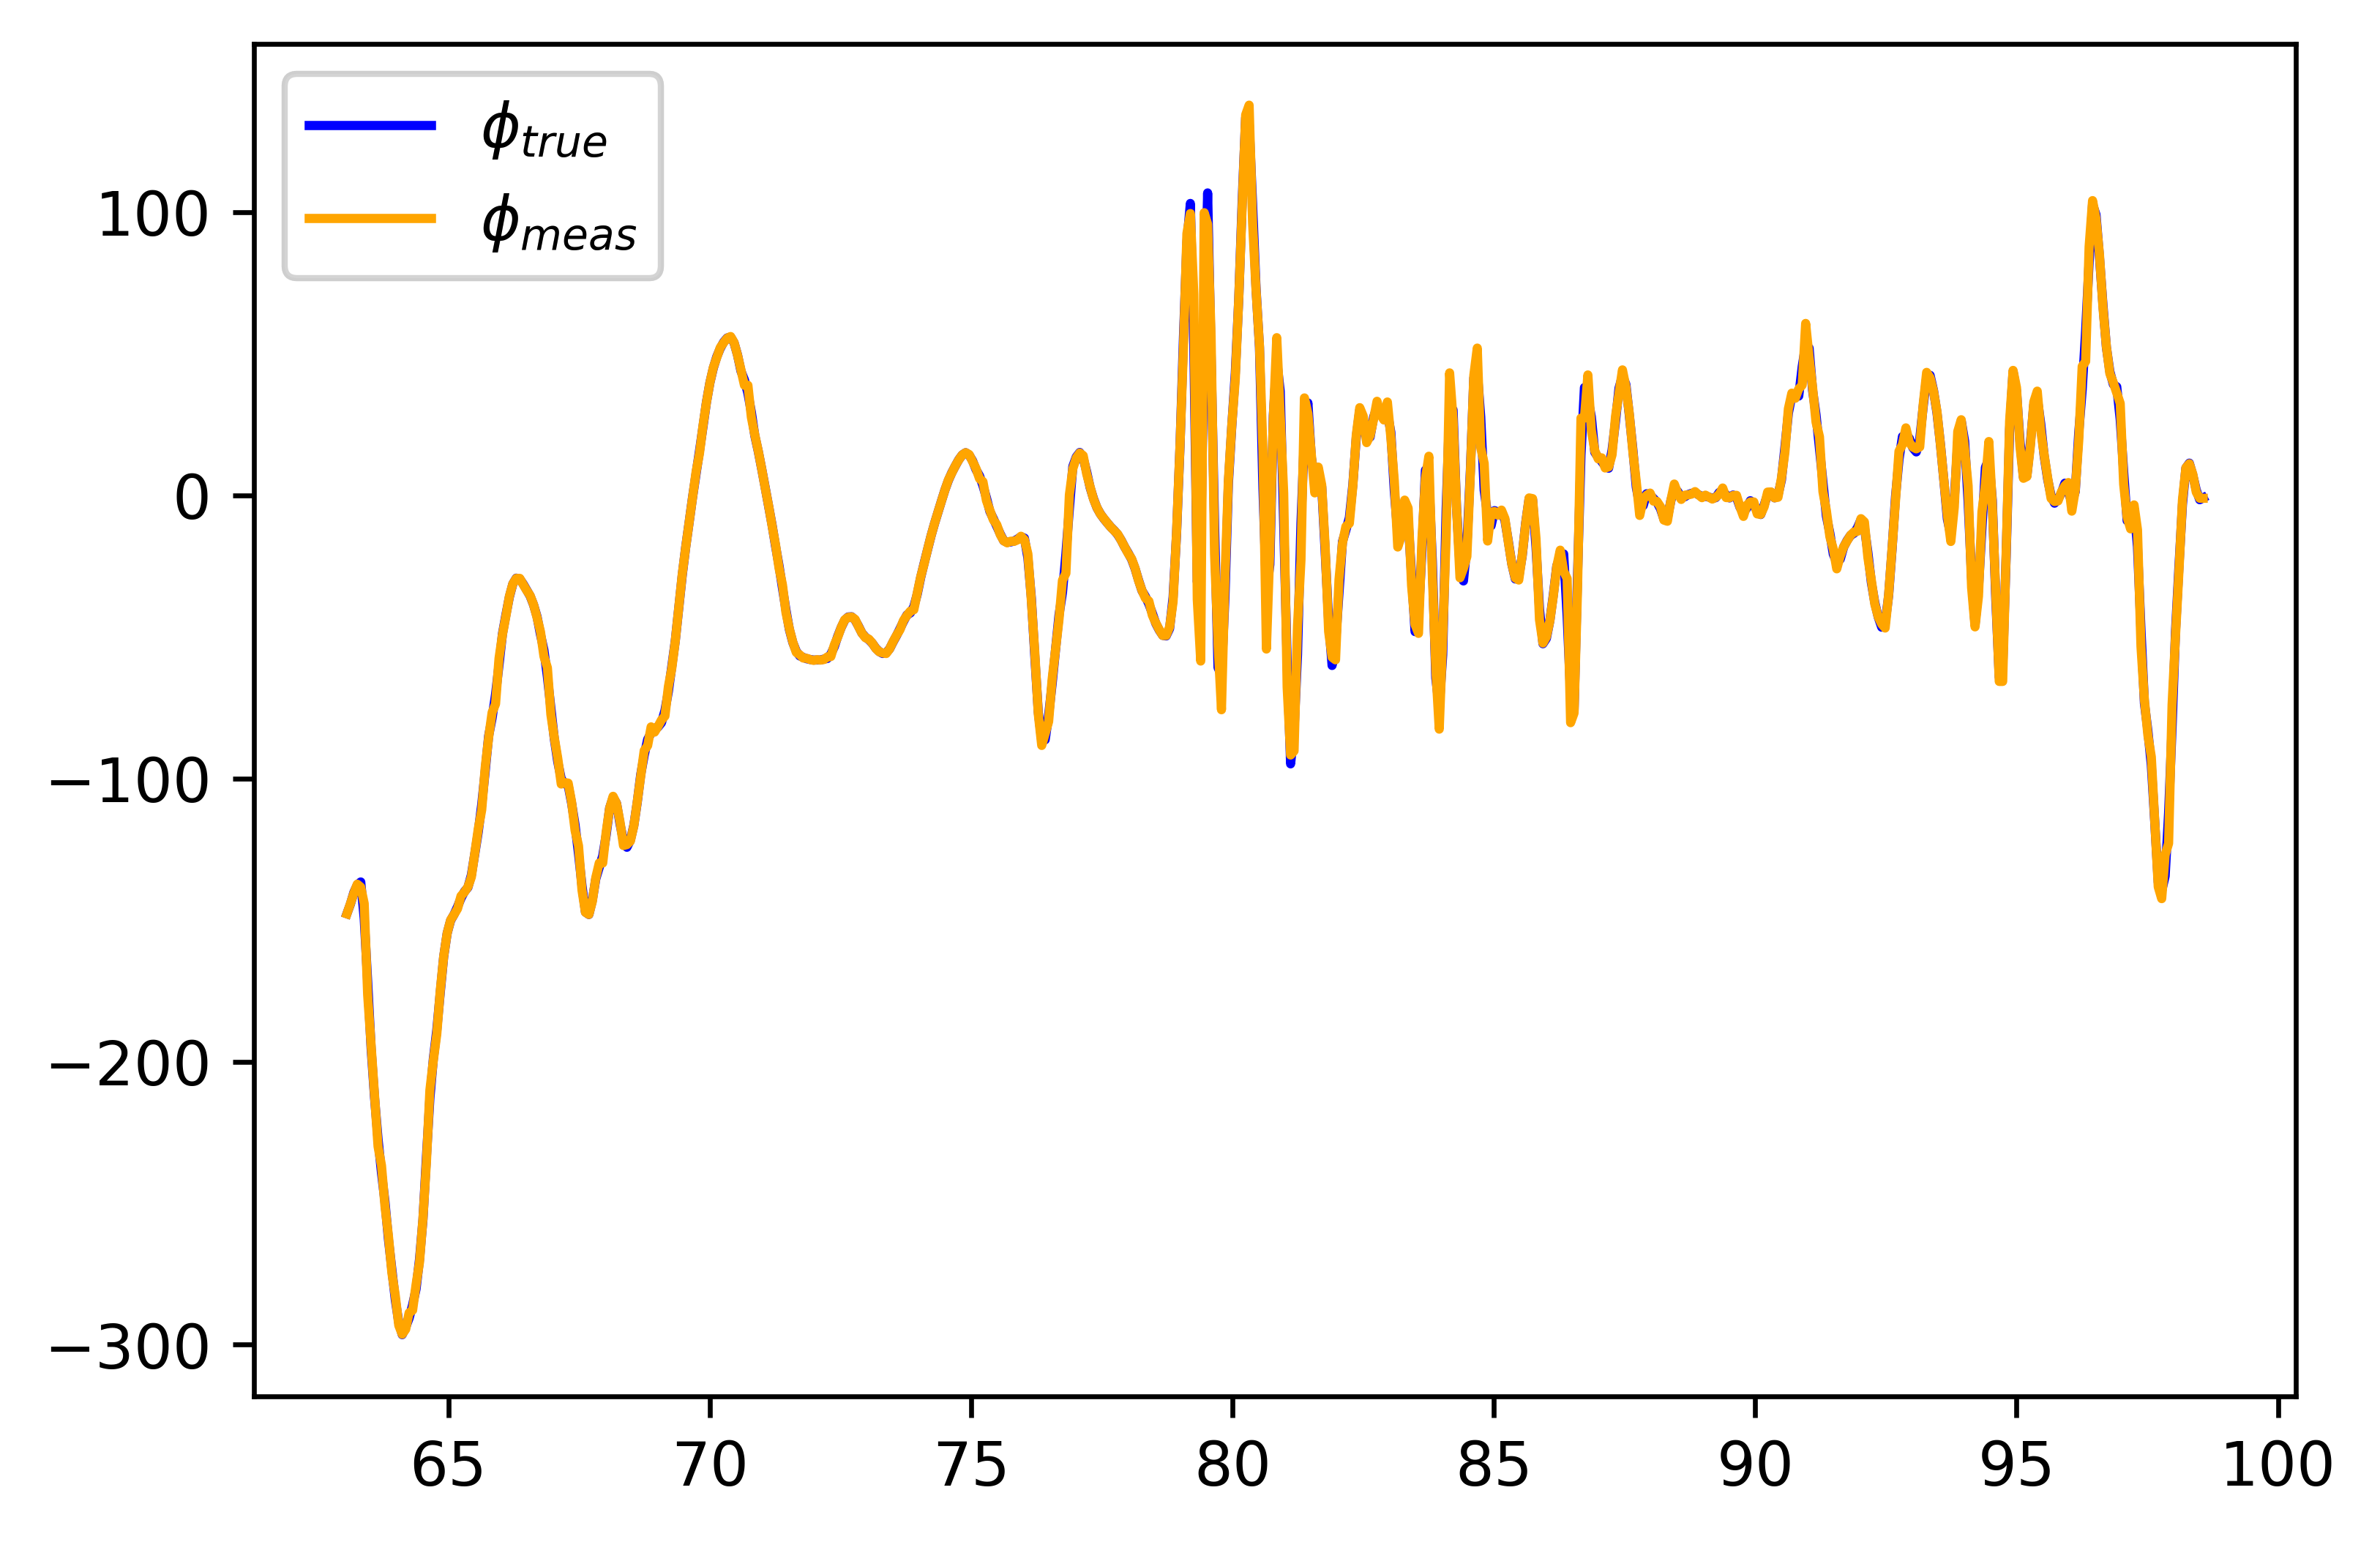

In [10]:
from matplotlib.colors import LinearSegmentedColormap
fig, axs = plt.subplots(1,1,dpi=300,figsize=(6,4))
true_plot = axs.plot(t, smoothed_phi, c='blue', label=r'$\phi_{true}$')
meas_plot = axs.plot(t, roll, c='orange', label=r'$\phi_{meas}$')
legend1 = axs.legend(handles=(true_plot[0], meas_plot[0]), loc='upper left')
axs.add_artist(legend1)
q_alphas = [1e-6,1e-5,1e-4,1e-3]
r_phis = [1e-6,1e-5,1e-4,1e-3]
scores = []
phi_hats = []
cmap = plt.get_cmap('autumn', len(q_alphas))
color1 = '#edc264'
color2 = '#ff002b'
colors = [color1, color2]
cmap = LinearSegmentedColormap.from_list("CustomGradient", colors, N=4)
colors = [cmap(i) for i in range(len(q_alphas))]
plt.gca().set_prop_cycle('color', colors)
hat_plots = []
# for r_phi in r_phis:
#     score, phi_hat = score_filter_params(r_phi=r_phi)
#     label = r'$\hat{\phi}$' + ' | ' + r'$\sigma_{\alpha}=$' + f'{r_phi:.1e} | RMSE={round(score,1)}'
#     hat_plot, = axs.plot(t, phi_hat, linewidth=1, label=label)
#     hat_plots.append(hat_plot)

# axs.legend(handles=hat_plots, loc='lower right')
#     scores.append(score)
#     phi_hats.append(phi_hat)
# t_arr = np.tile(t, (len(q_alphas),1))
# scores_arr = np.array(scores)
# phi_hats_arr = np.array(phi_hats)

# for i in range(len(q_alphas)):
#     label = r'$\hat{\phi}$' + ' | ' + r'$\sigma_{\alpha}=$' + f'{q_alpha:.3f} | RMSE={round(score,1)}'
#     axs.plot(t, phi_hats_arr[i], label=f'Line {i+1}')
#label = r'$\hat{\phi}$' + ' | ' + r'$\sigma_{\alpha}=$' + f'{q_alpha:.3f} | RMSE={round(score,1)}'
#hat_plot = axs.plot(t_arr, phi_hats_arr, linewidth=1)#, label=label)
#axs.legend(handles=[hat_plot[0]], loc='lower right')

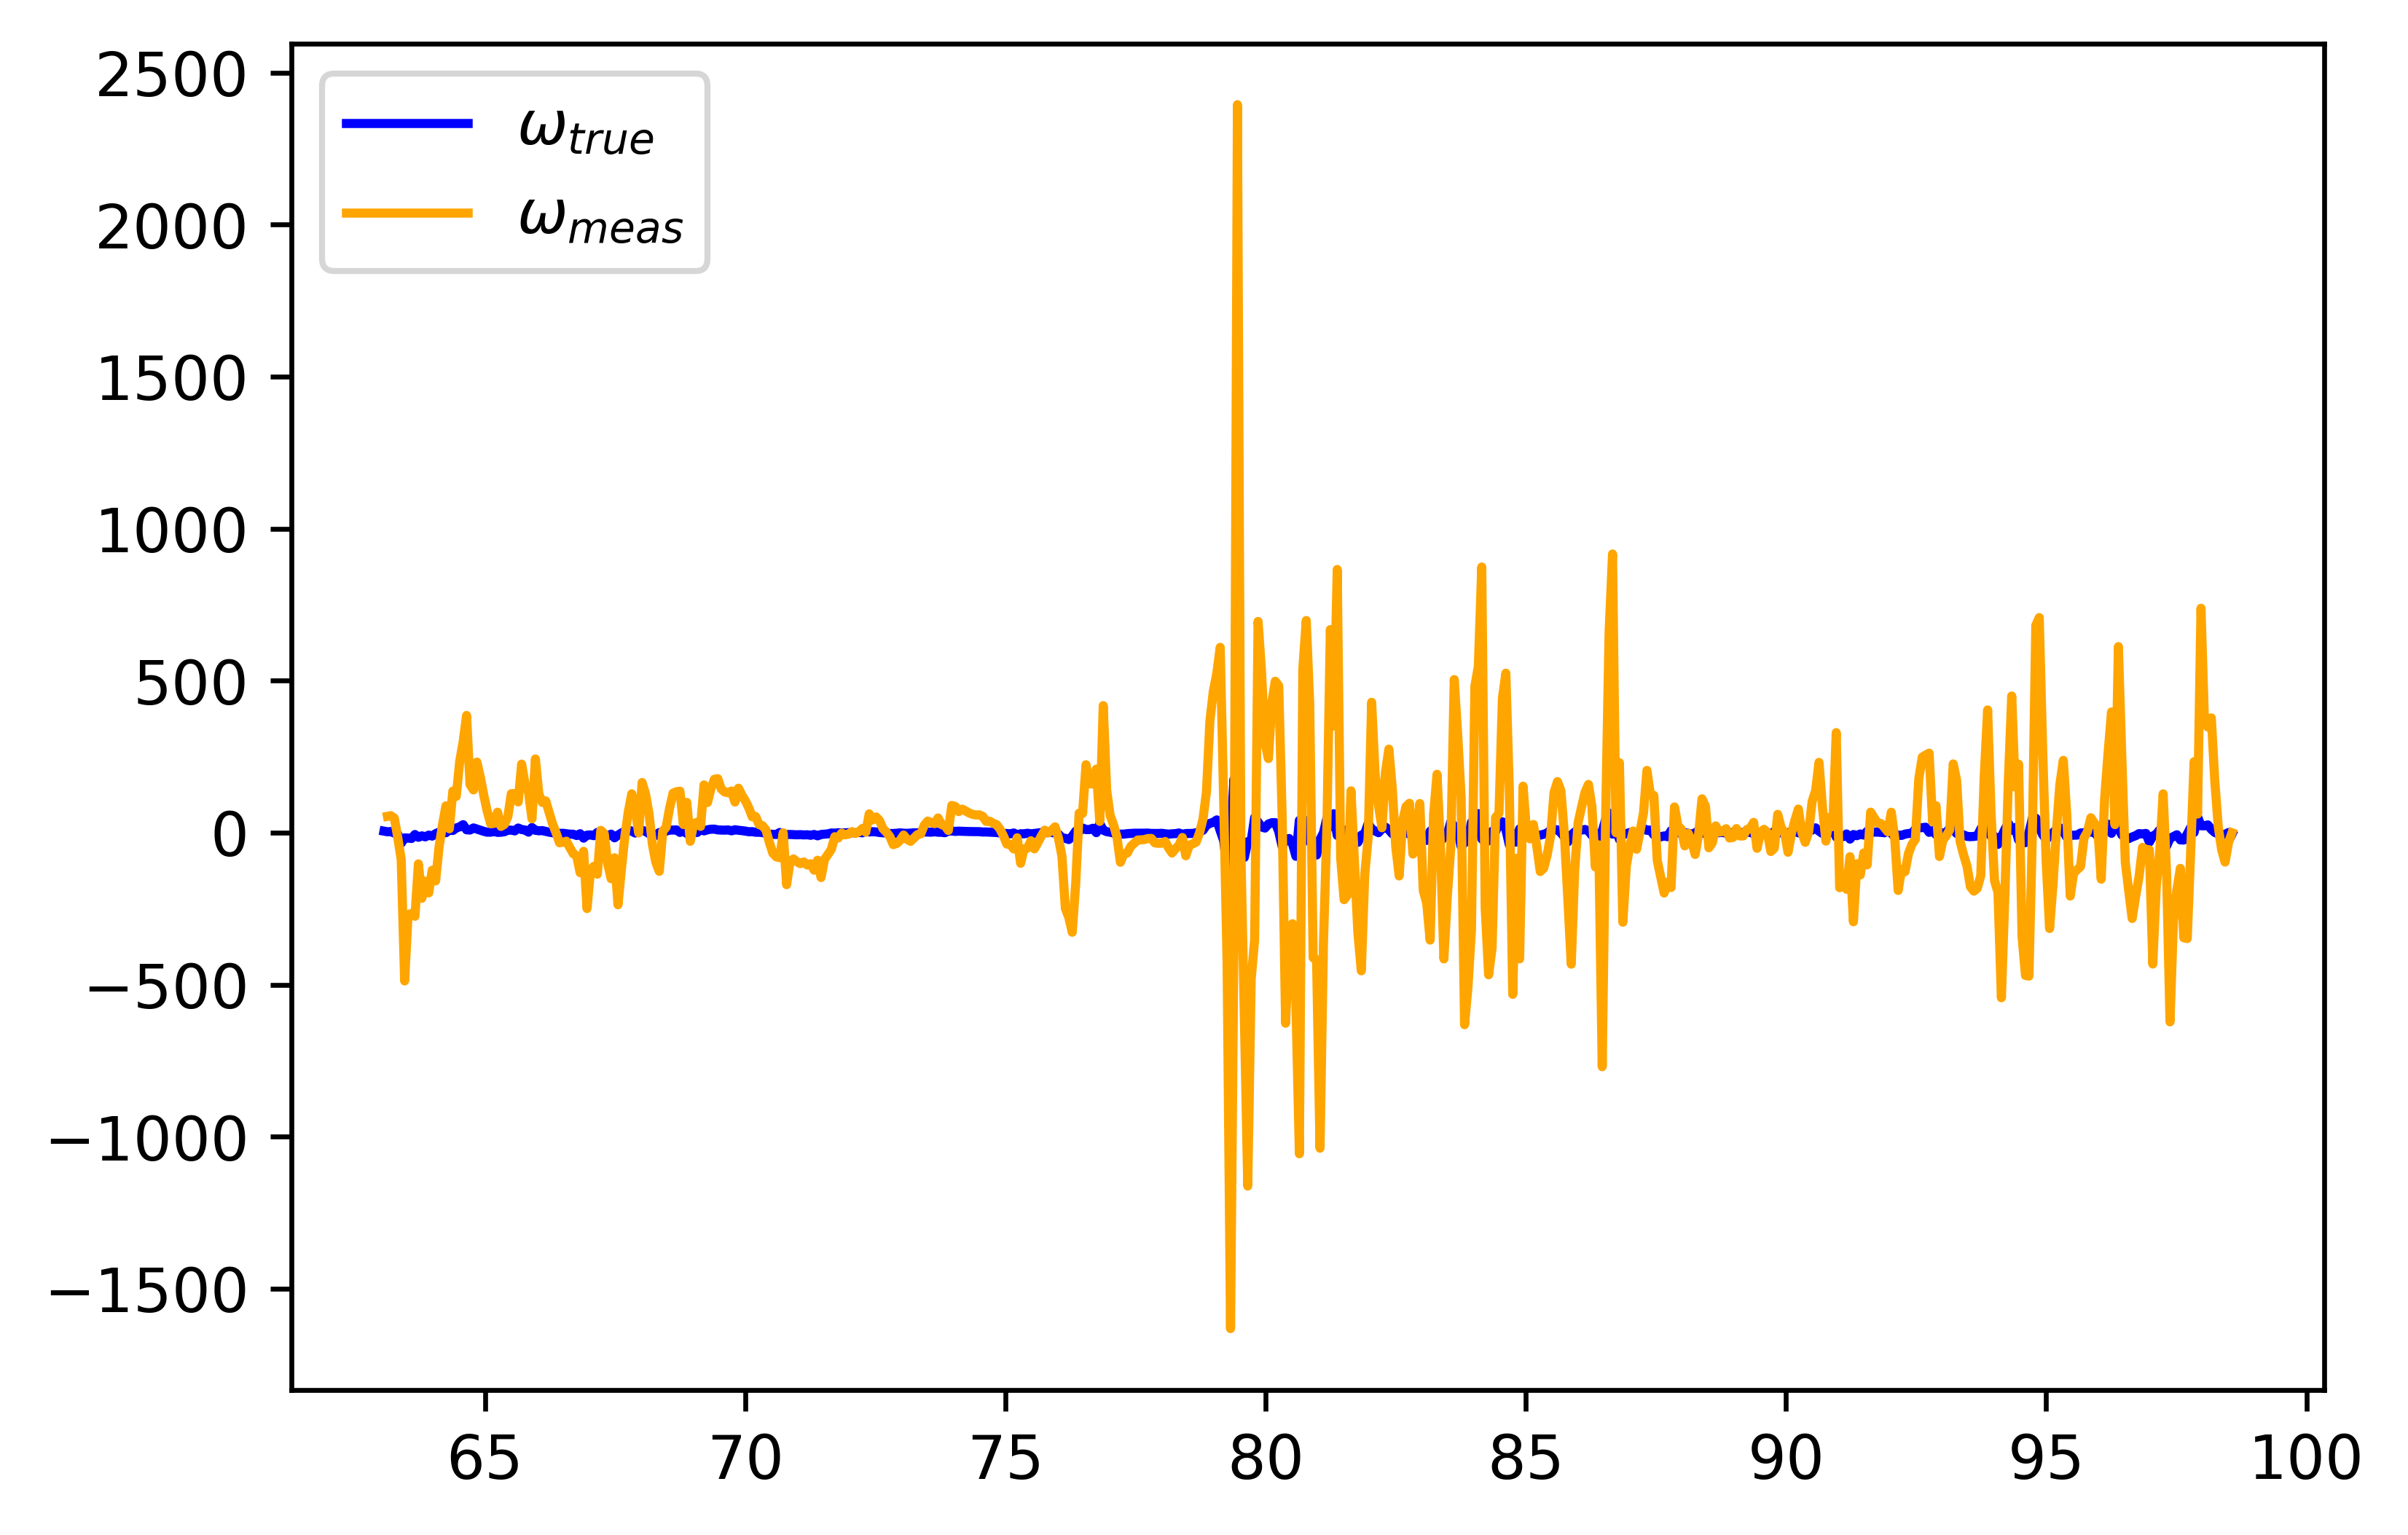

In [48]:
fig, axs = plt.subplots(1,1,dpi=300,figsize=(6,4))
true_plot = axs.plot(t, smoothed_omega, c='blue', label=r'$\omega_{true}$')
meas_plot = axs.plot(t[1:], omega, c='orange', label=r'$\omega_{meas}$')
legend1 = axs.legend(handles=(true_plot[0], meas_plot[0]), loc='upper left')
# axs.add_artist(legend1)
# q_alphas = [1e-6,1e-5,1e-4,1e-3]
# r_phis = [1e-6,1e-5,1e-4,1e-3]
# scores = []
# phi_hats = []
# cmap = plt.get_cmap('autumn', len(q_alphas))
# color1 = '#edc264'
# color2 = '#ff002b'
# colors = [color1, color2]
# cmap = LinearSegmentedColormap.from_list("CustomGradient", colors, N=4)
# colors = [cmap(i) for i in range(len(q_alphas))]
# plt.gca().set_prop_cycle('color', colors)
# hat_plots = []

In [50]:
t

array([63.06      , 63.12612663, 63.19225326, 63.25837989, 63.32450652,
       63.39063315, 63.45675978, 63.52288641, 63.58901304, 63.65513966,
       63.72126629, 63.78739292, 63.85351955, 63.91964618, 63.98577281,
       64.05189944, 64.11802607, 64.1841527 , 64.25027933, 64.31640596,
       64.38253259, 64.44865922, 64.51478585, 64.58091248, 64.64703911,
       64.71316574, 64.77929236, 64.84541899, 64.91154562, 64.97767225,
       65.04379888, 65.10992551, 65.17605214, 65.24217877, 65.3083054 ,
       65.37443203, 65.44055866, 65.50668529, 65.57281192, 65.63893855,
       65.70506518, 65.77119181, 65.83731844, 65.90344507, 65.96957169,
       66.03569832, 66.10182495, 66.16795158, 66.23407821, 66.30020484,
       66.36633147, 66.4324581 , 66.49858473, 66.56471136, 66.63083799,
       66.69696462, 66.76309125, 66.82921788, 66.89534451, 66.96147114,
       67.02759777, 67.09372439, 67.15985102, 67.22597765, 67.29210428,
       67.35823091, 67.42435754, 67.49048417, 67.5566108 , 67.62

### Grid Search

In [7]:
import pandas as pd

q_alphas = [1e-8,1e-6,1e-5,1e-4,1e-3]
r_phis = [1e-8,1e-6,1e-5,1e-4,1e-3]
r_omegas = [1e8,1e-6,1e-5,1e-4,1e-3]
uncertainties = []
scores = []
for q_alpha in q_alphas:
    for r_phi in r_phis:
        for r_omega in r_omegas:
            score, phi_hat = score_filter_params(q_alpha=q_alpha, r_phi=r_phi, r_omega=r_omega)
            uncertainties.append(np.array([q_alpha, r_phi, r_omega]))
            scores.append(score)
uncertainties = np.array(uncertainties)
scores = np.array(scores)[:, np.newaxis]

score_df = pd.DataFrame(data=np.hstack((uncertainties, scores)), columns=['q_alpha', 'r_phi', 'r_omega', 'RMSE'])

In [8]:
score_df.sort_values(by='RMSE')

,q_alpha,r_phi,r_omega,RMSE
16,1.000000e-08,0.00010,1.000000e-06,5.151396
42,1.000000e-06,0.00010,1.000000e-05,5.199508
22,1.000000e-08,0.00100,1.000000e-05,5.329201
21,1.000000e-08,0.00100,1.000000e-06,5.360713
73,1.000000e-05,0.00100,1.000000e-04,5.450723
...,...,...,...,...
14,1.000000e-08,0.00001,1.000000e-03,46.713318
10,1.000000e-08,0.00001,1.000000e+08,46.717711
19,1.000000e-08,0.00010,1.000000e-03,47.139690
20,1.000000e-08,0.00100,1.000000e+08,47.143780


### Simulate Data

In [11]:
span = [-np.pi, np.pi]
rng = np.random.default_rng(42)
num_samples = 1000
angles = np.zeros((num_samples, 3))
num_positions = 5
angular_positions = [rng.uniform(span[0], span[1], num_positions)]

# for axis, positions in enumerate(angular_positions):
#     indices = rng.integers(0, num_samples, num_positions)
#     angles[indices, axis] = positions

ranges = np.sort(rng.integers(0, num_samples, 2*num_positions)).reshape((num_positions, 2))
for axis, positions in enumerate(angular_positions):
    for idx, (start, end) in enumerate(ranges):
        angles[start:end, axis] = positions[idx]

In [23]:
def __gaussian_filter(in_data, window_size=50, sigma=5.0):
    x = np.linspace(-sigma*4, sigma*4, window_size)
    phi_x = np.exp(-x**2/(2.0*sigma**2))
    phi_x /= phi_x.sum()    # Normalization equivalent to the term 1/(sqrt(2*pi)*sigma)
    return np.correlate(in_data, phi_x, mode='same')

smooth_angles = np.array([__gaussian_filter(angles[:, i], window_size=50, sigma=5.0) for i in np.arange(3)]).T


In [29]:
smooth_angles[:,0]

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  

ValueError: x and y must have same first dimension, but have shapes (1,) and (1000,)

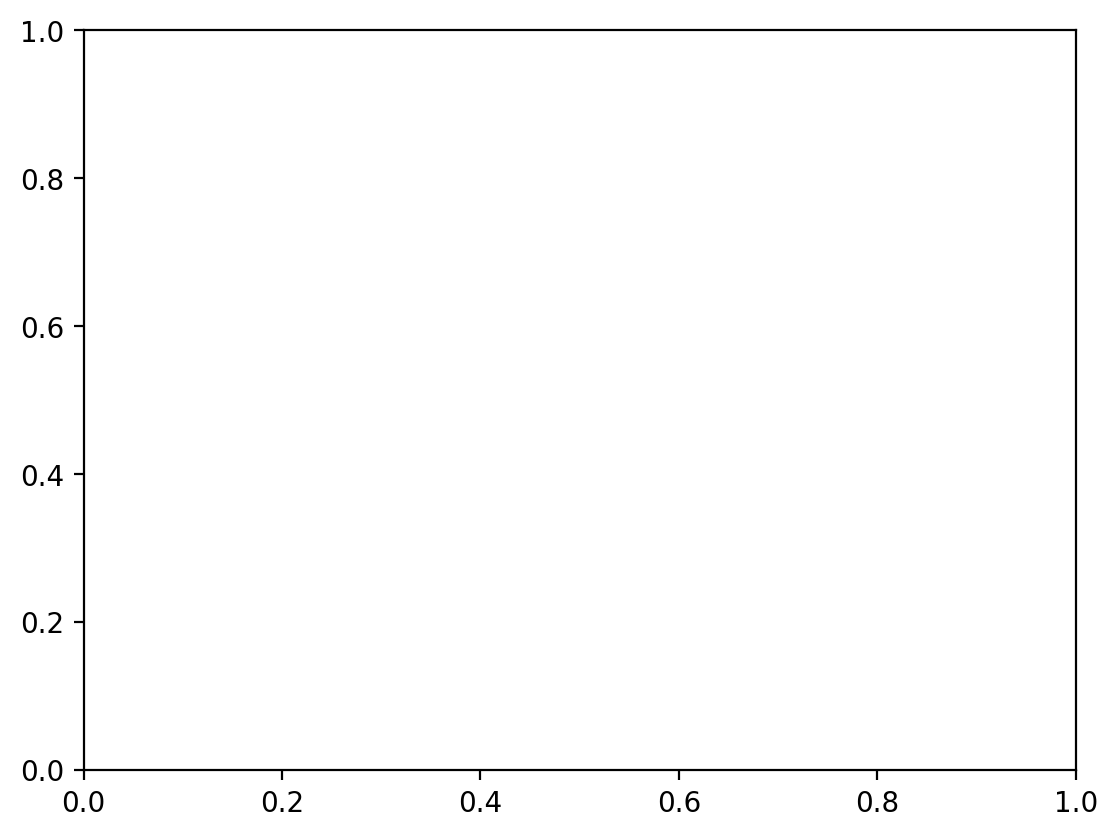

In [27]:
plt.plot(t_sim, smooth_angles[:,0])

In [ ]:
# Seed random number generator for reproducibility
rng = np.random.default_rng(42)

# Basic attributes
num_samples = 1000
num_positions = 5
span = [-np.pi, np.pi]  # Span of the Euler angles

# Start with no change in orientation (sensor is aligned with the global frame)
angles = np.zeros((num_samples, 3))

# Random angular positions
angular_positions = [rng.uniform(span[0], span[1], num_positions) for _ in np.arange(3)]

# Set a range for each angular position
ranges = np.sort(GENERATOR.integers(0, num_samples, 2*num_positions)).reshape((num_positions, 2))

# Distribute the angular positions
for axis, positions in enumerate(angular_positions):
    for idx, (start, end) in enumerate(ranges):
        angles[start:end, axis] = positions[idx]

# Smooth data for a better transition between positions
smooth_angles = __gaussian_filter(angles, size=40, sigma=20.0)

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [-3.56370378e-04,  0.00000000e+00,  0.00000000e+00],
       [-1.61353426e-04,  0.00000000e+00,  0.00000000e+00],
       [-5.57164347e-05,  0.00000000e+00,  0.00000000e+00]])

In [22]:
angles

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       ...,
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [18]:
dt = 0.01
angular_velocity = np.diff(smooth_angles, axis=0)/dt
angular_velocity = np.vstack((angular_velocity[0], angular_velocity))

t_sim = np.linspace(0, len(angular_positions), len(angular_positions))



In [21]:
smooth_angles

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [-3.56370378e-04,  0.00000000e+00,  0.00000000e+00],
       [-1.61353426e-04,  0.00000000e+00,  0.00000000e+00],
       [-5.57164347e-05,  0.00000000e+00,  0.00000000e+00]])

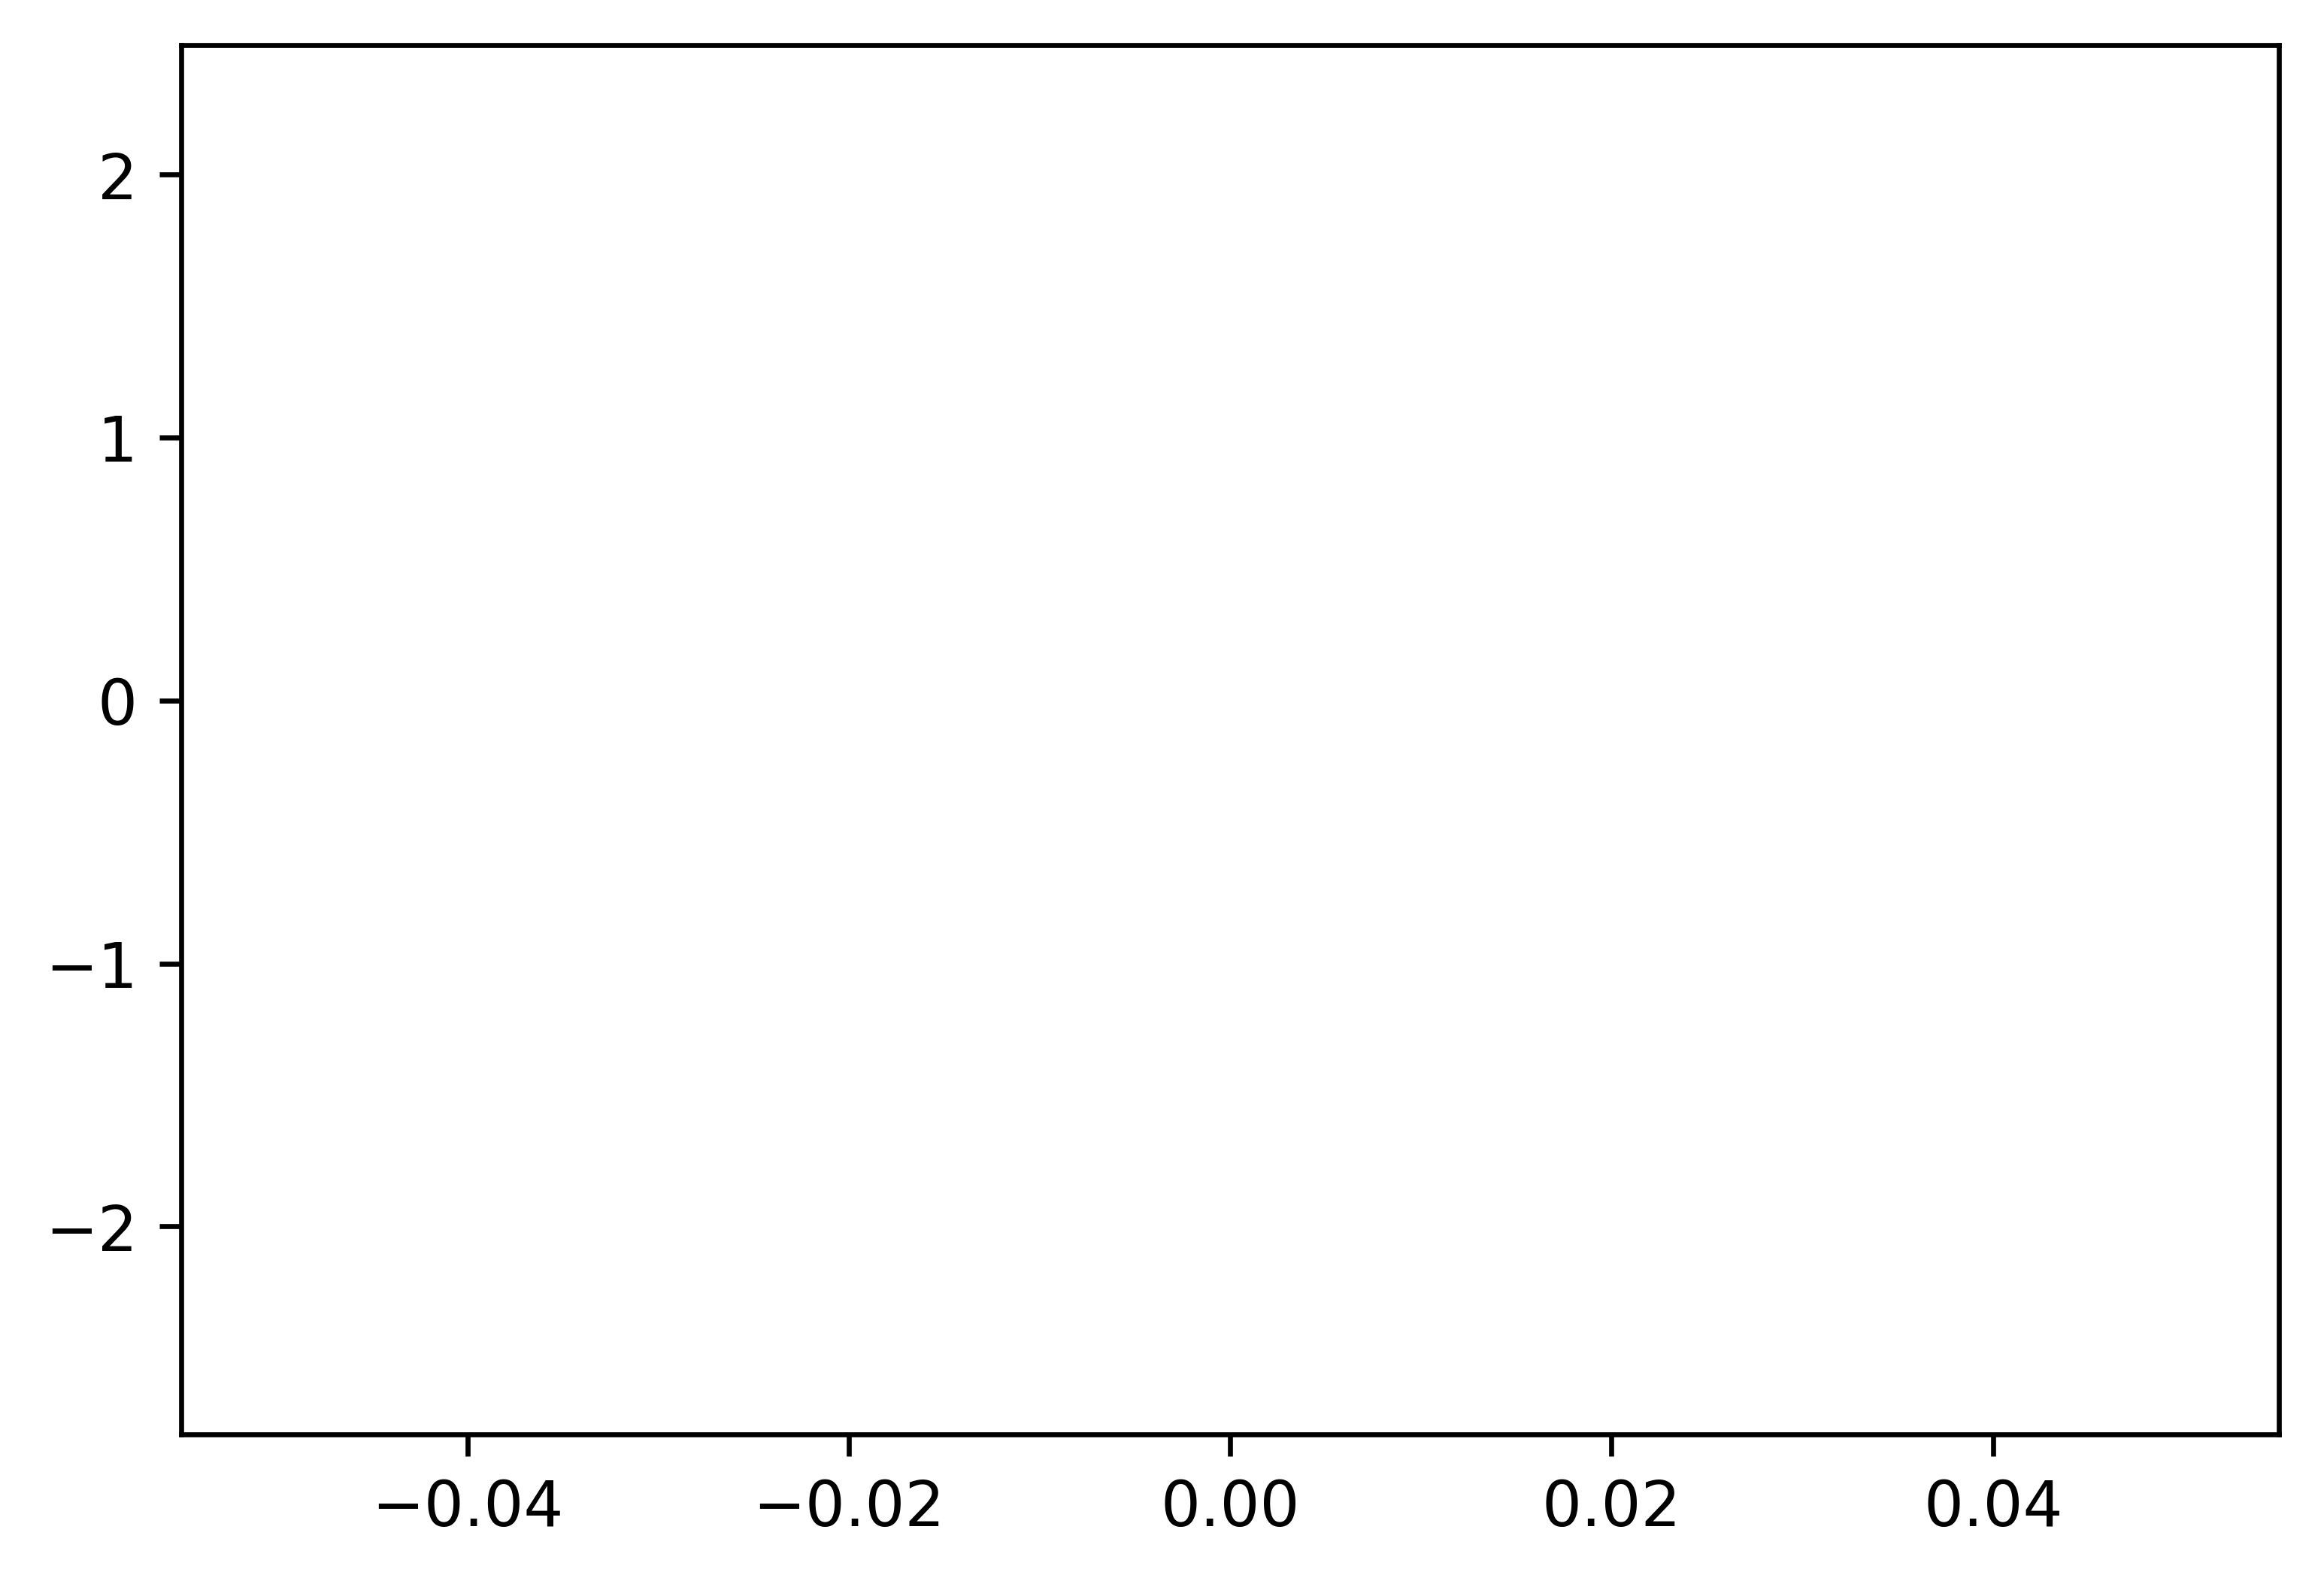

In [19]:
fig, axs = plt.subplots(1,1,dpi=300,figsize=(6,4))
axs.plot(t_sim, angular_positions, c='blue', label=r'$\phi_{true}$')
# meas_plot = axs.plot(t, roll, c='orange', label=r'$\phi_{meas}$')
# legend1 = axs.legend(handles=(true_plot[0], meas_plot[0]), loc='upper left')
# axs.add_artist(legend1)

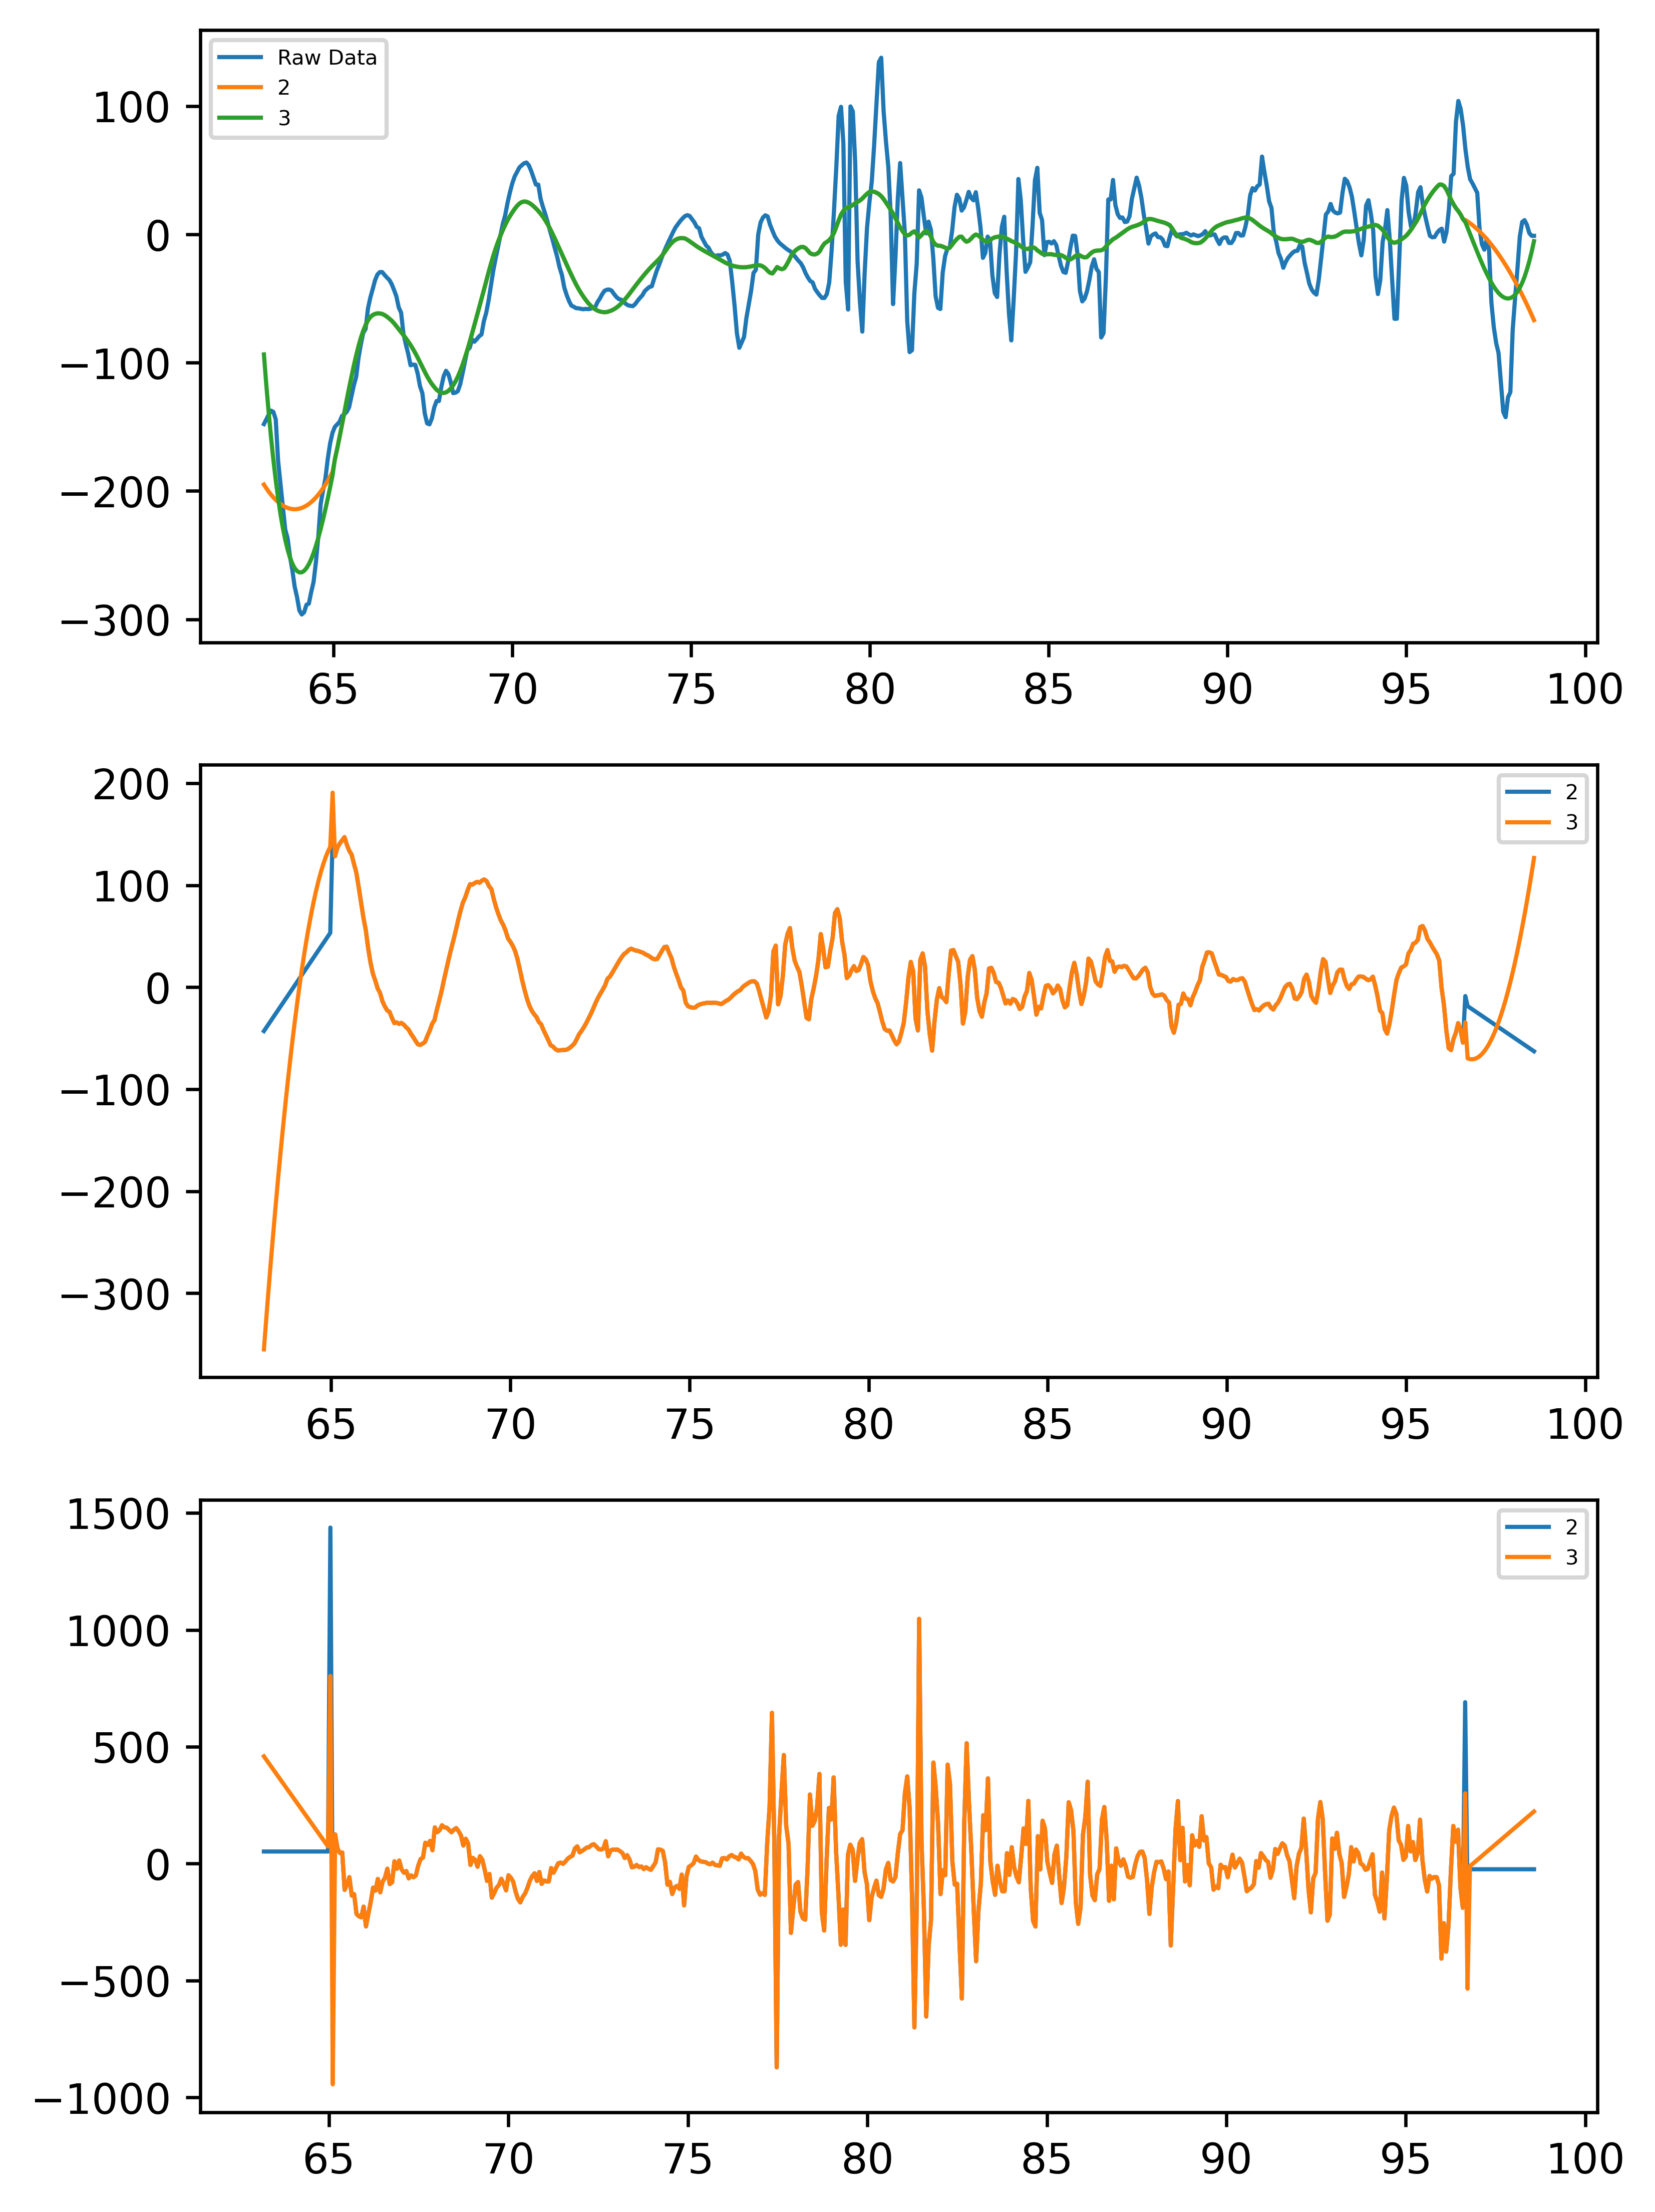

In [112]:
from scipy.signal import savgol_filter

fig, axs = plt.subplots(3,1,dpi=300,figsize=(6,9))

polyorders = [2,3]#,3,4,5]
smoothed_rolls = []
axs[0].plot(t, roll, linewidth=1, label='Raw Data')
# axs[0].plot(t, omega, label='Raw Data')
# axs[2].plot(t, alpha, label='Raw ')
for order in polyorders:
    smoothed_phi = savgol_filter(roll, window_length=60, polyorder=order)
    #smoothed_rolls.append(smoothed_)
    smoothed_omega = np.diff(smoothed_phi) / dt
    smoothed_alpha = np.diff(smoothed_omega) / dt
    axs[0].plot(t, smoothed_phi, linewidth=1, label=f'{order}')
    axs[1].plot(t[1:], smoothed_omega, linewidth=1, label=f'{order}')
    axs[2].plot(t[2:], smoothed_alpha, linewidth=1, label=f'{order}')
axs[0].legend(fontsize=5)#, title='Polynomial Order')
axs[1].legend(fontsize=5)#, title='Polynomial Order')
axs[2].legend(fontsize=5);#, title='Polynomial Order')
# plt.grid(lw=2,ls=':')
# plt.xlabel('Time Step')
# plt.ylabel("Value")
# plt.legend()
# plt.show()


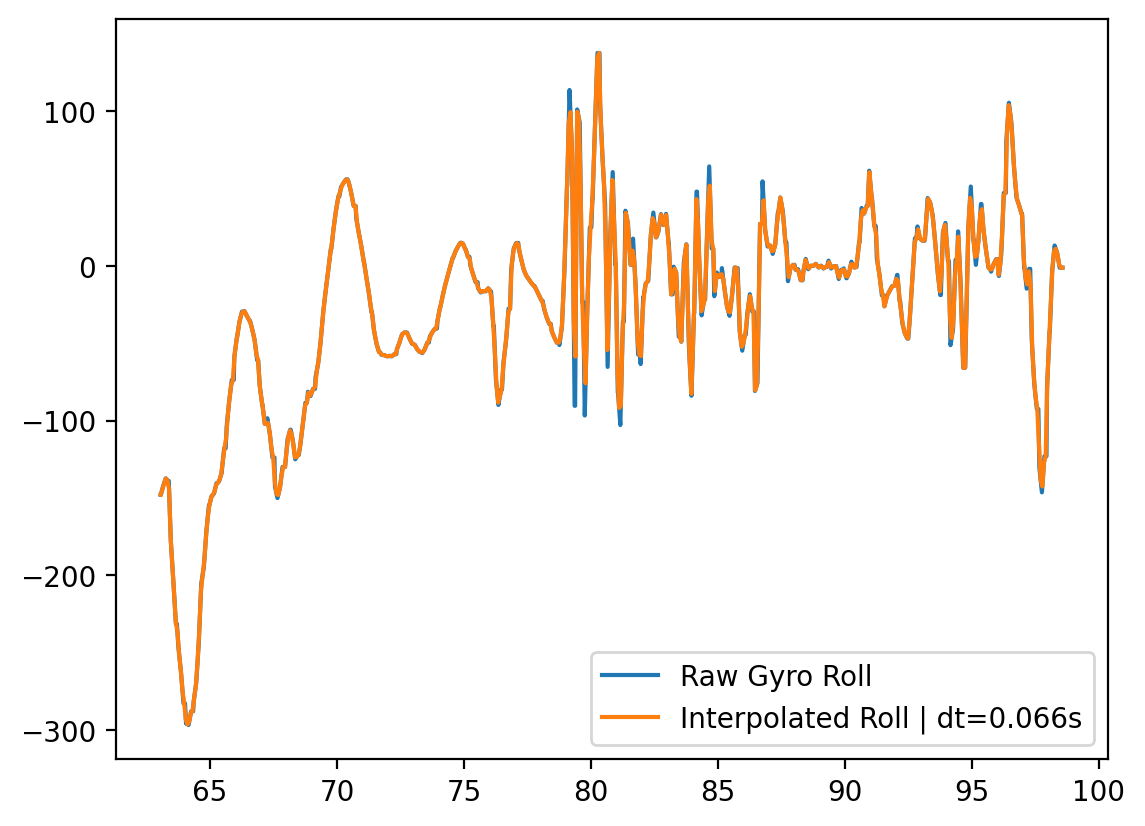

In [ ]:
plt.plot(xr, yr, label='Raw Gyro Roll')
plt.plot(t, roll, label=f'Interpolated Roll | dt={round(dt,3)}s')
plt.legend()
plt.show()

avg. time:  2.6507061977365367e-05


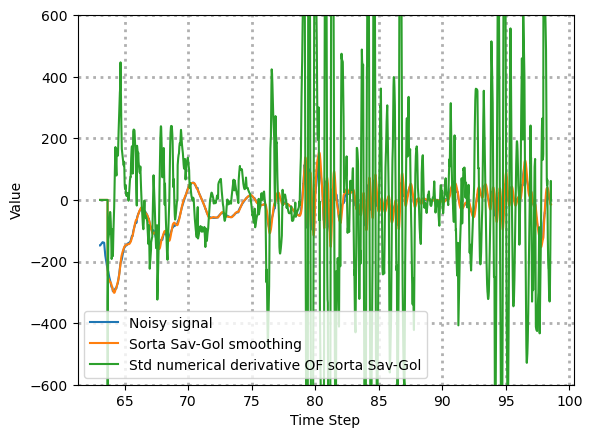

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import time
#warnings.simplefilter('ignore', np.exceptions.RankWarning)

xres = 0.01

# interpolates (x,y) at xres (100hz)
x = np.arange(xr[0],xr[-1],xres)
y = np.interp(x,xr,yr)

totalTime = 0

# this because i'm not a good programmer
dy = 0 * y
fy = 0 * y
nfy = 0 * y
ny = 0 * y
bfy = 0 * y

# sorta Sav-Gol
winSize = 60
for i in range(winSize,len(y)):
    start_time = time.perf_counter()
    ywin = y[i-winSize:i] - [0]*winSize
    xwin = x[i-winSize:i] - [x[i]]*winSize
    py = np.polyfit(xwin,ywin,2)
    dy[i] = py[1]
    fy[i] = py[2]
    # std numerical derivative OF sorta Sav-Gol
    nfy[i] = (fy[i]-fy[i-1])/xres
    totalTime += time.perf_counter() - start_time

for i in range(winSize,len(y)-winSize):
    ywin = y[i-winSize:i+winSize] - [0]*(2*winSize)
    xwin = x[i-winSize:i+winSize] - [x[i]]*(2*winSize)
    py = np.polyfit(xwin,ywin,2)
    bfy[i] = py[2]

print("avg. time: ",totalTime / len(y))

plt.ylim(-600,600)

plt.plot(x, y, label='Noisy signal')
plt.plot(x, fy, label='Sorta Sav-Gol smoothing')
#plt.plot(x, bfy, label='Full Sav-Gol smoothing')
#plt.plot(x, dy, label='Sorta Sav-Gol derivative')
plt.plot(x, nfy, label='Std numerical derivative OF sorta Sav-Gol')
#plt.plot(x, ny, label='Std numerical derivative')
plt.grid(lw=2,ls=':')
plt.xlabel('Time Step')
plt.ylabel("Value")
plt.legend()
plt.show()


avg. time:  4.042026457531256e-06


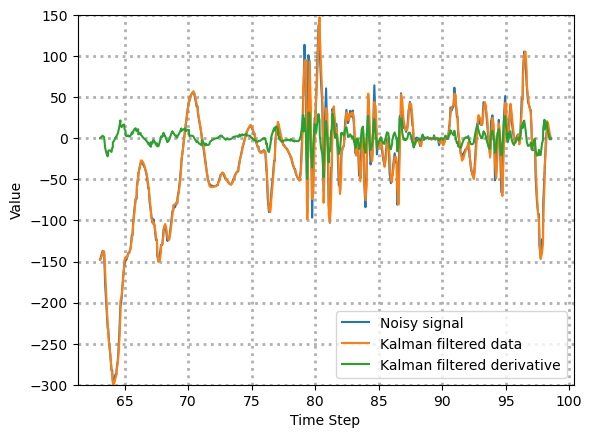

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import time

ys = 0 * yr
dy = 0 * yr
ny = 0 * yr
totalTime = 0

class KalmanSys:
    def __init__(self, A, H, Q, R, x, P):
        self.A = A
        self.H = H
        self.Q = Q
        self.R = R
        self.K = 0
        self.x = x0
        self.P = P0

    def update(self):
        self.x = np.dot(self.A, self.x) # predict next step
        self.P = np.dot(self.A, np.dot(self.P, np.transpose(self.A))) + self.Q #predict uncertainty in next step
        self.K = np.dot(np.dot(self.P,np.transpose(self.H)), np.linalg.inv(np.dot(self.H,np.dot(self.P, np.transpose(H))) + self.R))
        self.P = self.P - np.dot(self.K, np.dot(self.H, self.P))

    def estimate(self, z): # z is the measurement
        self.x = self.x + np.dot(self.K, (z - np.dot(self.H, self.x)))
        return self.x
        
dt = 1

# state transition matrix
A = np.array([[1, dt],
              [0, 1]])
# state measurement matrix
H = np.array([[1, 0],
              [0, 0]])
# state transition noise
Q = np.array([[0.1, 0],
              [0, 0.1]])
# state measurement noise
R = np.array([[0.8, 0],
              [0, 1]])
# initial state
x0 = np.array([yr[0],0])

# initial covariance matrix
P0 = np.array([[0.8, 0],
               [0, 0]])

KS = KalmanSys(A, H, Q, R, x0, P0)

for i in range(0,len(yr)-1):
    start_time = time.perf_counter()
    A = np.array([[1, xr[i + 1] - xr[i]],
              [0, 1]])
    KS.update()
    ys[i] = KS.estimate(yr[i])[0]
    dy[i] = KS.estimate(yr[i])[1]
    totalTime += time.perf_counter() - start_time
    
print("avg. time: ",totalTime / len(y))

plt.ylim(-300,150)
plt.plot(xr, yr, label='Noisy signal')
plt.plot(xr, ys, label='Kalman filtered data')
plt.plot(xr, dy, label='Kalman filtered derivative')
plt.grid(lw=2,ls=':')
plt.xlabel('Time Step')
plt.ylabel("Value")
plt.legend()
plt.show()